# Pythonプログラミング応用 演習課題（全10問）


## 基礎編

## 課題1：合計の計算（for または sum）

1から100までの数字を合計し出力するコードを、for文またはsum()関数を使って作成してください。

In [33]:
# for文で計算
total_for = 0
for i in range(1, 101):
    total_for += i
print("for文:", total_for)

# sum()で計算
total_sum = sum(range(1, 101))
print("sum():", total_sum)

for文: 5050
sum(): 5050


## 課題2：うるう年判定
次のリストに入っている年について、それぞれがうるう年か平年かを判定してください。
```
years = [1900, 2000, 2024, 2025]
```

判定ルール：
* 400で割り切れる → うるう年
* 100で割り切れる → 平年
* 4で割り切れる → うるう年
* それ以外 → 平年

In [14]:
years = [1900, 2000, 2024, 2025]

def is_leap(y: int) -> bool:
    if y % 400 == 0:
        return True
    if y % 100 == 0:
        return False
    return y % 4 == 0

for y in years:
    print(f"{y}: {'うるう年' if is_leap(y) else '平年'}")

1900: 平年
2000: うるう年
2024: うるう年
2025: 平年


## NumPy編

## 課題3：NumPy配列の演算（2倍・2乗）

NumPy を使って 1 から 10 までの配列を作り、

各要素を2倍にした配列

各要素を2乗した配列をそれぞれ出力してください。


In [17]:
import numpy as np

arr = np.arange(1, 11)
print("元配列:", arr)
print("2倍   :", arr * 2)
print("2乗   :", arr ** 2)

元配列: [ 1  2  3  4  5  6  7  8  9 10]
2倍   : [ 2  4  6  8 10 12 14 16 18 20]
2乗   : [  1   4   9  16  25  36  49  64  81 100]


## 課題4：多次元配列の集計（行合計・列合計）

次の配列を作成して
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

* 行ごとの合計
* 列ごとの合計

をそれぞれ求めてください。


In [19]:
import numpy as np

mat = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])
print("行ごとの合計:", mat.sum(axis=1))
print("列ごとの合計:", mat.sum(axis=0))

行ごとの合計: [ 6 15 24]
列ごとの合計: [12 15 18]


## 課題5：DataFrameの作成と抽出

次のデータを DataFrame で作成してください。

| 名前 | 年齢 | 点数 |
|:-----|:-----|:----|
| 田中 |	20 |	80 |
| 鈴木 |	21 |	90 |
| 佐藤 |	19 |	70 |

* 「名前」列を表示してください
* 点数80点以上の行を抽出してください

In [22]:
import pandas as pd

df = pd.DataFrame({
    "名前": ["田中", "鈴木", "佐藤"],
    "年齢": [20, 21, 19],
    "点数": [80, 90, 70],
})
display(df)

print("\n【名前列】")
display(df["名前"])

print("\n【点数>=80】")
display(df[df["点数"] >= 80])

,名前,年齢,点数
0,田中,20,80
1,鈴木,21,90
2,佐藤,19,70



【名前列】


,名前
0,田中
1,鈴木
2,佐藤



【点数>=80】


,名前,年齢,点数
0,田中,20,80
1,鈴木,21,90


## 課題6：列の追加（合否）と統計量

課題5の DataFrame に「合否」列を追加してください

合否条件： 80点以上＝合格、それ以外＝不合格）

さらに「点数」の平均値・最大値・最小値を出力してください。

In [23]:
df2 = df.copy()
df2["合否"] = ["合格" if s >= 80 else "不合格" for s in df2["点数"]]
display(df2)

print("\n平均:", df2["点数"].mean())
print("最大:", df2["点数"].max())
print("最小:", df2["点数"].min())

,名前,年齢,点数,合否
0,田中,20,80,合格
1,鈴木,21,90,合格
2,佐藤,19,70,不合格



平均: 80.0
最大: 90
最小: 70


## 課題7：折れ線グラフ（matplotlib）
次のデータを matplotlib で折れ線グラフにしてください。

```
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
temps = [22, 24, 26, 25, 27, 29, 28]
```
* タイトル「1週間の気温の推移」
* X軸：曜日
* Y軸：気温（℃）
* マーカー付き

注意：日本語が文字化するときは "!pip install japanize-matplotlib" を実行して、"import japanize_matplotlib"を追加してください

In [24]:
!pip install japanize-matplotlib

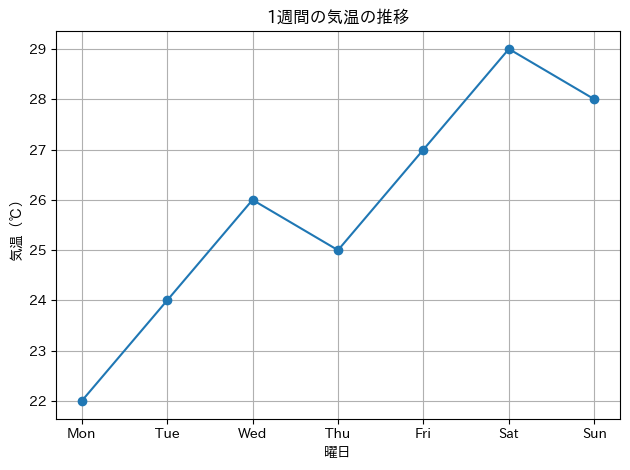

In [25]:
# Colabでは最初にインストールが必要です
# !pip install japanize-matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib
days  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
temps = [22, 24, 26, 25, 27, 29, 28]

plt.plot(days, temps, marker="o")  # 色指定はしない
plt.title("1週間の気温の推移")
plt.xlabel("曜日")
plt.ylabel("気温（℃）")
plt.grid(True)
plt.tight_layout()
plt.show()

## 地理空間編

## 課題8： 緯度・経度の扱い
東京駅から新宿駅までの直線距離（km）を計算してください。

* 東京駅（緯度 35.6812, 経度 139.7671）
* 新宿駅（緯度 35.6900, 経度 139.7000）

計算方法は、mathモジュールの三角関数を用いる または geopyライブラリのどちらかを使用して計算してください

In [28]:
# 解答例①：math モジュールを用いた実装（球面三角法 / haversine 公式）
import math

# 東京駅と新宿駅の座標（緯度・経度）
tokyo = (35.6812, 139.7671)
shinjuku = (35.6900, 139.7000)

# 地球半径（km）
R = 6371.0

# ラジアンに変換
lat1 = math.radians(tokyo[0])
lon1 = math.radians(tokyo[1])
lat2 = math.radians(shinjuku[0])
lon2 = math.radians(shinjuku[1])

# haversine 公式
dlat = lat2 - lat1
dlon = lon2 - lon1
a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
distance = R * c

print(f"東京駅から新宿駅までの距離（math使用）: {distance:.2f} km")


東京駅から新宿駅までの距離（math使用）: 6.14 km


In [34]:
# 解答例②：geopy ライブラリを用いた実装
from geopy.distance import geodesic

tokyo = (35.6812, 139.7671)
shinjuku = (35.6900, 139.7000)

distance = geodesic(tokyo, shinjuku).kilometers
print(f"東京駅から新宿駅までの距離（geopy使用）: {distance:.2f} km")


東京駅から新宿駅までの距離（geopy使用）: 6.15 km


## 課題9：leafmap でマップ表示（マーカー）
leafmap を使って、東京駅を中心に地図を表示してください。

* ベースマップを「HYBRID」に切り替える
* 各駅のマーカーで追加してください
  * 東京駅（35.6812, 139.7671）
  * 新宿駅（35.6900, 139.7000）
  * 渋谷駅（35.6580, 139.7016）


In [36]:
# Colabでは最初にインストールが必要です（実行時に有効）
# !!pip -q install leafmap

import leafmap

# 地図の中心を東京駅に設定して地図を作成
m = leafmap.Map(center=(35.6812, 139.7671), zoom=12)

# ベースマップをHYBRIDに切り替え
m.add_basemap('HYBRID')

# マーカーを追加
markers = {
    '東京': (35.6812, 139.7671),
    '新宿': (35.6900, 139.7000),
    '渋谷': (35.6580, 139.7016)
}

for name, location in markers.items():
    # ポップアップに駅名を設定してマーカーを追加
    m.add_marker(location)

# 地図を表示
m

Map(center=[35.6812, 139.7671], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

## 課題10：folium でマップ表示（マーカークラスタ）
folium を用い、東京駅を中心に地図を作り、同じ3駅を マーカークラスタ で可視化してください


In [37]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[35.6812, 139.7671], zoom_start=12)
cluster = MarkerCluster().add_to(m)

stations = {
    "Tokyo":    [35.6812, 139.7671],
    "Shinjuku": [35.6900, 139.7000],
    "Shibuya":  [35.6580, 139.7016],
}
for name, loc in stations.items():
    folium.Marker(location=loc, popup=name).add_to(cluster)

# 地図を表示
m
